In [1]:
import numpy as np
import matplotlib.pyplot as plt
from crab_propagation_tools import make_controls_fn
from blochstate1d_NEW import OLConstants, GroundBlochState
from ga_individual_maker import make_controls_fn1

In [2]:
data = np.load('best_solution.npz')
A = data['A'][0,:]
B = data['B'][0,:]
omegas = data['omegas'][0,:]

In [3]:
shaking_function = make_controls_fn(OLConstants.N_elements,A, B, omegas,OLConstants.T)


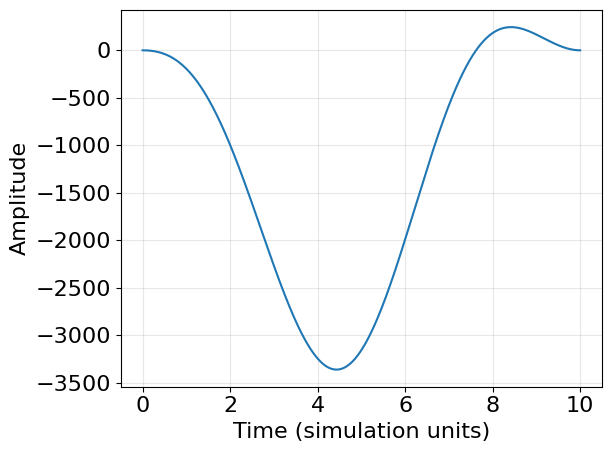

<Figure size 640x480 with 0 Axes>

In [4]:
x = np.linspace(0, 10, 10000)
y = shaking_function(x)

time_domain = np.linspace(0.0, 10.0, 10001)

phi_values = np.array([shaking_function(x) for x in time_domain])
# real_time = np.linspace(0.0, 250, 10001)


plt.rcParams['font.size'] = 16
plt.figure()
plt.plot(time_domain, phi_values,linewidth=1.5, color='tab:blue')
plt.xlabel("Time (simulation units)")
plt.ylabel("Amplitude")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()
plt.savefig('GA_shaking_function_plot.png', dpi=300)

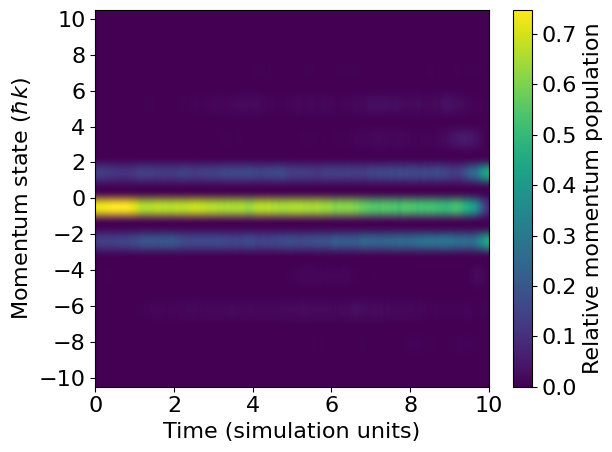

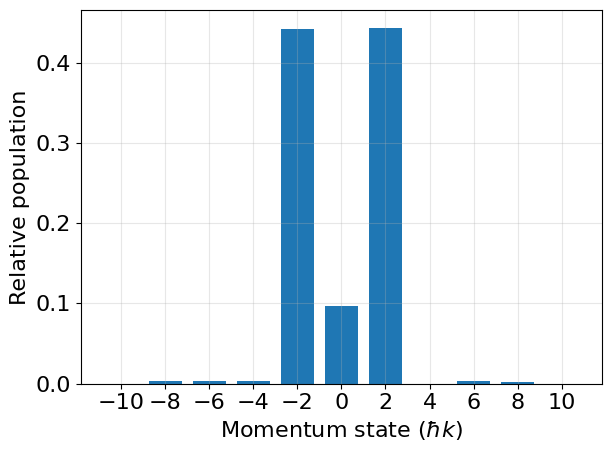

In [13]:
from blochstate1d_NEW import GroundBlochState, OLConstants
import numpy as np
import time
from typing import Optional, cast
from quevolutio.core.domain import QuantumHilbertSpace, TimeGrid
from quevolutio.core.aliases import (  # isort: skip
    RVector,
    GVector,
    RVectorSeq,
    CTensors,
    CSRMatrix,
)
from crab_propagation_tools import OpticalLatticeHamiltonian
from quevolutio.propagators.split_operator import SplitOperator
from errors_momentum_space import momentum_space_population
import matplotlib.pyplot as plt
constants: OLConstants = OLConstants()

initial_state = GroundBlochState().generate_bloch_state()
x_grid_spacing = GroundBlochState().x_grid[1] - GroundBlochState().x_grid[0]

constants: OLConstants = OLConstants()
domain: QuantumHilbertSpace = QuantumHilbertSpace(
        num_dimensions=1,
        num_points=np.array([constants.num_pts]),
        position_bounds=np.array([[constants.lower_x_bound, constants.upper_x_bound]]),
        constants=constants,
    )
state_initial: RVector = cast(
        RVector, domain.normalise_state(initial_state)
    )

hamiltonian: OpticalLatticeHamiltonian = OpticalLatticeHamiltonian(domain)

#controls_fn = make_controls_fn(OLConstants.N_elements,A, B, omegas,OLConstants.T)
controls_fn = make_controls_fn1(OLConstants.T, A, B, omegas)
time_domain: TimeGrid = TimeGrid(time_min=0.0, time_max=constants.T, num_points=10001)
propagator = SplitOperator(hamiltonian, time_domain)

states: CTensors = propagator.propagate(
        state_initial, controls_fn, diagnostics=False
    )

n_samples = 2000
sample_indices = np.linspace(0, len(states) - 1, n_samples, dtype=int)
n_p = constants.n_p
populations = np.zeros((n_p, n_samples))

for j, i in enumerate(sample_indices):
    psi = states[i]
    populations[:, j] = momentum_space_population(psi, x_grid_spacing)
time_grid = np.linspace(0.0, constants.T, len(states))
time_sampled= time_grid[sample_indices]

# Padding the population array to create gaps between momentum states in the plot
factor = 2  

n_p, n_t = populations.shape
pop_padded = np.zeros((n_p * factor, n_t))


momentum_vals = np.arange(-10, 11, 2)  # [-10, -8, ..., 10]
n_p = len(momentum_vals)

pop_padded = np.zeros((n_p * factor, n_t))
for i in range(n_p):
    pop_padded[i * factor] = populations[i]

extent = [
    time_sampled[0],
    time_sampled[-1],
    momentum_vals[0] - 0.5,
    momentum_vals[-1] + 0.5,
]


plt.rcParams['font.size'] = 16
plt.imshow(
    pop_padded,
    aspect='auto',
    origin='lower',
    extent=extent,
    cmap='viridis'
)

plt.yticks(momentum_vals)
plt.ylim(momentum_vals[0] - 0.5, momentum_vals[-1] + 0.5)
plt.xlabel('Time (simulation units)')
plt.ylabel(r'Momentum state ($\hbar k$)')
plt.colorbar(label='Relative momentum population')
plt.tight_layout()
plt.savefig('splitting_over_time.pdf') 
plt.show()


#plot the final momentum distribution at the end of the shaking function
final_momentum_distribution = populations[:, -1]
plt.figure()
plt.bar(momentum_vals, final_momentum_distribution, width=1.5, color='C0')
plt.xlabel(r'Momentum state ($\hbar k$)')
plt.xticks(momentum_vals)
plt.ylabel('Relative population')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('final_momentum_distribution.pdf')
plt.show()

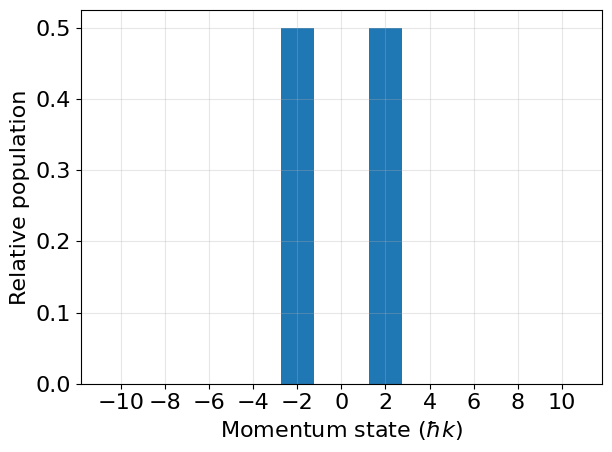

In [15]:
#plot of desired momentum state
from blochstate1d_NEW import OLConstants
constants: OLConstants = OLConstants()

plt.bar(momentum_vals, constants.desired_mom_pop, width=1.5, color='C0')
plt.xlabel(r'Momentum state ($\hbar k$)')
plt.xticks(momentum_vals)
plt.ylabel('Relative population')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('desired_momentum_distribution.pdf')
plt.show()